> **Group:** Sara Martinez Rendon (1000424179) | Heider Zapata (1000009586) | Yeison Londoño (1000009479)  
> **Master's Degree in Data Sciences** | EAFIT University  
> **Course:** Applied Mathematics  
> **Date:** 05/03/2026
---

# **Trabajo Final - Matemáticas Aplicadas en Ciencia de Datos**

---

## **Datos**

>Utilizaremos el Olivetti Faces Dataset (fácilmente disponible vía sklearn.datasets.fetch_olivetti_faces en Python). Este conjunto contiene 400 imágenes en escala de grises de $64 × 64$ píxeles, correspondientes a $40$ sujetos distintos ($10$ imágenes por persona). Cada imagen deberá ser “aplanada” a un vector $x ∈ R^{4096}$, formando nuestra matriz de diseño principal $X$ de dimensiones $400 × 4096$.
>
>Junto con las imágenes, la función de descarga proporcionará un arreglo unidimensional de etiquetas (target) que contiene valores enteros del $0$ al $39$. Cada valor en este arreglo indica exactamente a cuál de los $40$ sujetos pertenece la fila correspondiente en la matriz $X$, una herramienta indispensable para filtrar y estructurar el problema de clasificación más adelante.
>
>Para evaluar las técnicas de detección de anomalías, inyectaremos una imagen intrusa determinista. Deberán crear mediante código un vector en $R^{4096}$ donde la primera mitad de los elementos tenga un valor de $1.0$ (blanco) y la segunda mitad tenga un valor de $0.0$ (negro). Esta estructura artificial nos garantizará un comportamiento atípico en el análisis estadístico.

Primero, necesitamos descargar el dataset Olivetti Faces. Este contiene 400 imágenes de 64x64 píxeles (que aplanaremos a vectores de 4096 elementos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces #carga olivetti faces dataset

In [9]:
# Descargamos el dataset completo
print("Descargando dataset...")
dataset = fetch_olivetti_faces(shuffle=True, random_state=42) #shuffle=True => mezcla el orden de las imágenes

# Extraemos la matriz X y las etiquetas y
# Las imágenes ya vienen aplanadas en la propiedad '.data'
X = dataset.data        # Matriz de 400 x 4096 (nuestras imágenes aplanadas)
y = dataset.target      # # Arreglo de 400 etiquetas (0 al 39) que indican a qué sujeto pertenece cada imagen
images = dataset.images # la propiedad '.images' permite ver las imágenes en su formato original de cuadrícula [Matriz original de 400 x 64 x 64 (solo para visualizar más fácil)]

print("")
print(f"Dimensión de los tensores que albergan las imagenes originales: {images.shape}")
print(f"Dimensión de la matriz X (con las imagenes ya aplanadas): {X.shape}")
print(f"Dimensión de las etiquetas y: {y.shape}")

Descargando dataset...

Dimensión de los tensores que albergan las imagenes originales: (400, 64, 64)
Dimensión de la matriz X (con las imagenes ya aplanadas): (400, 4096)
Dimensión de las etiquetas y: (400,)


---

## **Tarea 1: El Espacio Original y Métricas de Similitud**

### **(a) Seleccionen una imagen “ancla” de un sujeto. Utilizando operaciones vectoriales puras, calculen la distancia Euclidiana (L2) y la similitud del Coseno (derivada del producto interno y la norma) entre esta ancla y el resto de las imágenes del dataset.**

En este punto, trataremos cada imagen como un punto en un hiperespacio gigantesco de $4096$ dimensiones ($X ∈ R^{4096}$). Queremos ver qué tan bien funcionan las matemáticas básicas para saber si dos caras se parecen. Vamos a tomar la primera imagen como nuestra "ancla" y calcularemos las métricas operando directamente sobre las matrices y vectores con `numpy`.

* Distancia Euclidiana ($L_2$): Mide la magnitud de la diferencia espacial directa entre dos vectores $x$ e $y$.

$$d_{L2}(x, y) = \|x - y\|_2 = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$$

* Similitud del Coseno: Mide el ángulo entre dos vectores, ignorando su magnitud. Se calcula con el producto punto dividido por la magnitud de ambos vectores.

$$\text{Similitud}(x, y) = \cos(\theta) = \frac{x \cdot y}{\|x\|_2 \|y\|_2}$$

In [11]:
 # --- MÉTRICAS DE SIMILITUD ---

# Seleccionamos la imagen índice 0 como nuestra ancla
idx_ancla = 0
ancla = X[idx_ancla]

# 1. Distancia Euclidiana (L2) - Pura operación vectorial
# Restamos el ancla a todas las filas de X, elevamos al cuadrado, sumamos por fila y sacamos raíz
distancias_l2 = np.sqrt(np.sum((X - ancla)**2, axis=1))

# Similitud del Coseno
# Fórmula: (A dot B) / (||A|| * ||B||)
# Calculamos el producto punto del ancla con todas las demás imágenes
producto_punto = np.dot(X, ancla)

# Calculamos las normas (magnitudes)
norma_ancla = np.linalg.norm(ancla)
normas_X = np.linalg.norm(X, axis=1)

# Similitud del coseno (valores más cercanos a 1 significan mayor similitud)
similitud_coseno = producto_punto / (normas_X * norma_ancla)

### **(b) Mediante código, encuentren las 3 imágenes más cercanas al ancla según la métrica L2 y las 3 más cercanas según el Coseno. Visualícenlas en una figura con dos filas.**

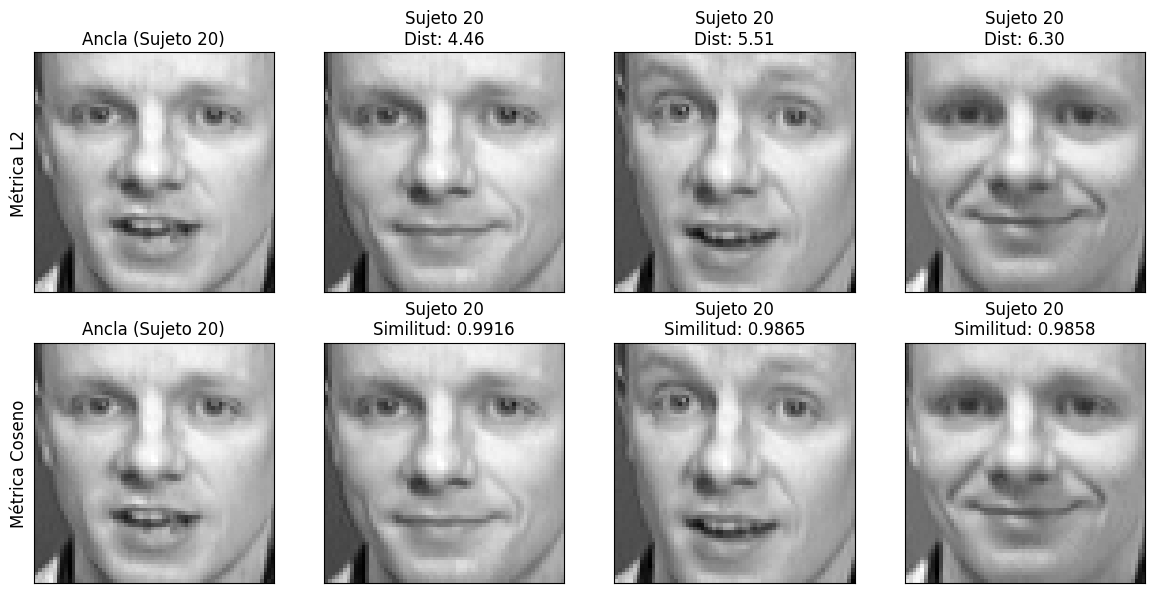

In [ ]:
# --- ENCONTRAR LAS MÁS CERCANAS ---

# argsort devuelve los índices ordenados. 
# Para L2 queremos los valores más PEQUEÑOS (menor separación física entre sí)
# [1:4] porque el índice 0 será el ancla misma (distancia 0)
top3_l2_idx = np.argsort(distancias_l2)[1:4]

# Para Coseno queremos los valores más GRANDES (cercanos a 1 -> cos(0°) = 1 -> alta similitud). 
# argsort ordena de menor a mayor, así que invertimos el arreglo con [::-1]
top3_coseno_idx = np.argsort(similitud_coseno)[::-1][1:4]

# --- VISUALIZACIÓN ---
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

# Título de las filas
axes[0, 0].set_ylabel("Métrica L2", fontsize=12)
axes[1, 0].set_ylabel("Métrica Coseno", fontsize=12)

# Mostrar Ancla en la primera columna
for i in range(2):
    axes[i, 0].imshow(images[idx_ancla], cmap='gray')
    axes[i, 0].set_title(f"Ancla (Sujeto {y[idx_ancla]})")
    axes[i, 0].set_xticks([])
    axes[i, 0].set_yticks([])

# Mostrar Top 3 para L2
for i, idx in enumerate(top3_l2_idx):
    axes[0, i+1].imshow(images[idx], cmap='gray')
    axes[0, i+1].set_title(f"Sujeto {y[idx]}\nDist: {distancias_l2[idx]:.2f}")
    axes[0, i+1].set_xticks([])
    axes[0, i+1].set_yticks([])

# Mostrar Top 3 para Coseno
for i, idx in enumerate(top3_coseno_idx):
    axes[1, i+1].imshow(images[idx], cmap='gray')
    axes[1, i+1].set_title(f"Sujeto {y[idx]}\nSimilitud: {similitud_coseno[idx]:.4f}")
    axes[1, i+1].set_xticks([])
    axes[1, i+1].set_yticks([])

plt.tight_layout()
plt.show()

### **(c) Discusión: ¿Las imágenes más cercanas corresponden a la misma persona? ¿Por qué la distancia Euclidiana directa sobre píxeles es estadísticamente frágil si la persona mueve ligeramente la cabeza o hay un cambio global en la iluminación?**

Al observar los resultados para nuestra imagen ancla, evidenciamos que las 3 imágenes más cercanas obtenidas mediante la distancia Euclidiana ($L_2$) y la similitud del Coseno coinciden exactamente, tanto en las imágenes seleccionadas como en su orden. Además, las tres corresponden efectivamente a la misma persona del ancla. De acuerdo con la librería, este alto grado de acierto se podría deber a que el conjunto de datos de Olivetti presenta condiciones sumamente controladas: los rostros están previamente alineados, centrados y sobre un fondo homogéneo, lo que favorece temporalmente la comparación directa de píxeles en $\mathbb{R}^{4096}$.

No obstante, calcular la distancia $L_2$ directamente sobre los píxeles crudos es un enfoque estadísticamente frágil en sistemas biométricos reales debido a dos factores matemáticos:

* Sensibilidad extrema al movimiento (Desalineación espacial): Si la persona mueve ligeramente la cabeza o cambia su postura, el píxel $x_i$ que antes registraba la pupila oscura ahora se comparará con un píxel $y_i$ correspondiente a la piel clara. Dado que la métrica calcula $d_{L2}(x,y) = \sqrt{\sum_{i=1}^{4096} (x_i - y_i)^2}$, estas diferencias al cuadrado penalizan drásticamente el resultado. El algoritmo no comprende la estructura facial global; solo percibe un desajuste numérico masivo, disparando la distancia global.

* Sensibilidad a cambios de iluminación (Desplazamiento de magnitud): la distancia Euclidiana mide la magnitud pura entre dos puntos en el espacio. Si a la misma persona se le toma una fotografía idéntica pero con mayor iluminación global, el valor de los píxeles aumentará por un factor o constante $c$. Al comparar la imagen original $x$ con la iluminada $y = x + c$, la distancia sería $d_{L2}(x, x+c) = \sqrt{\sum_{i=1}^{4096} (-c)^2} = 64c$. Aunque la topología del rostro sea exactamente la misma, la métrica los clasificará como entidades muy lejanas en el espacio, fallando en reconocer la identidad.

---

## **Tarea 2: Factorización Matricial y Eigenfaces**

Extraeremos las direcciones de máxima varianza para reducir drásticamente la dimensionalidad.

### **(a) Centren la matriz de datos X restando el vector de la media global (el “rostro promedio”).**

Dimensiones de la matriz de rostro promedio: (4096,)

Dimensiones de X original: (400, 4096)
Dimensiones de X centrada: (400, 4096)


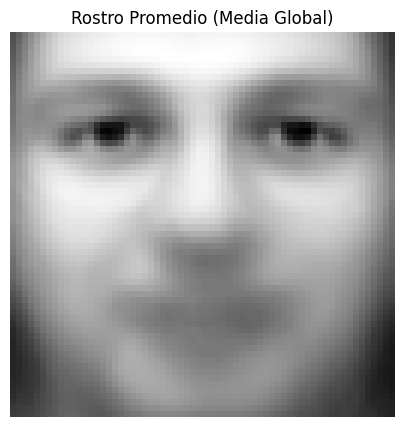

In [17]:
# --- CENTRAR LOS DATOS ---
# Calcular el rostro promedio (media a lo largo de las columnas/características -> media de cada píxel a través de las 400 imágenes)
rostro_promedio = np.mean(X, axis=0)

# Centramos la matriz restando este promedio a cada imagen
X_centrada = X - rostro_promedio


# Verificamos las dimensiones para asegurar que no cambiaron
print(f"Dimensiones de la matriz de rostro promedio: {rostro_promedio.shape}") # Debería ser (4096,) porque es un vector aplanado del rostro promedio
print()
print(f"Dimensiones de X original: {X.shape}")
print(f"Dimensiones de X centrada: {X_centrada.shape}")

# --- Visualización del Rostro Promedio ---
plt.figure(figsize=(5, 5))
# Recordamos redimensionar el vector de 4096 a 64x64 para poder graficarlo
plt.imshow(rostro_promedio.reshape(64, 64), cmap='gray')
plt.title("Rostro Promedio (Media Global)")
plt.axis('off')
plt.show()

### **(b) Utilicen la Descomposición en Valores Singulares (SVD) Reducida para encontrar los componentes principales.**

En álgebra lineal, la SVD descompone nuestra matriz $X$ en el producto de tres matrices: 

$$X = U \Sigma V^T$$

$U$: Matriz de vectores singulares izquierdos.

$\Sigma$ (en código suele llamarse S): Matriz diagonal con los valores singulares.

$V^T$: Matriz de vectores singulares derechos transpuestos (nuestros famosos componentes principales).

Dado que nuestra matriz $X$ tiene dimensiones $400 \times 4096$, el rango máximo de la matriz es 400. Si calculáramos la SVD completa, $V^T$ sería una matriz gigantesca de $4096 \times 4096$, donde la inmensa mayoría de las filas estarían vacías (dimensiones nulas). Al usar la versión "reducida", le decimos al algoritmo que solo calcule los primeros 400 componentes útiles.

In [19]:

# --- SVD (Singular Vector Decomposition) REDUCIDA ---
# El parámetro full_matrices=False nos asegura calcular la SVD reducida, 
# evitando computar dimensiones nulas ineficientes.
# NO usamos librerías PCA preconstruidas.

print("Calculando SVD...")
U, S, Vt = np.linalg.svd(X_centrada, full_matrices=False)

print(f"Dimensiones de U: {U.shape}")
# S se devuelve como un vector 1D con los valores de la diagonal para ahorrar memoria
print(f"Dimensiones de S (Valores Singulares): {S.shape}") 
print(f"Dimensiones de V transpuesta (Vt): {Vt.shape}")

Calculando SVD...
Dimensiones de U: (400, 400)
Dimensiones de S (Valores Singulares): (400,)
Dimensiones de V transpuesta (Vt): (400, 4096)


### **(c) ¿Qué es un Eigenface? Es simplemente un vector propio (una fila de la matriz VT) que ha sido re-dimensionado a su forma original de imagen de 64 × 64. Estos representan los “bloques de construcción” visuales de los rostros. Seleccionen las primeras 5 filas de VT, reformateen estos vectores a imágenes y visualícenlas en una cuadrícula de 1 fila y 5 columnas.¿Qué características capturan?**

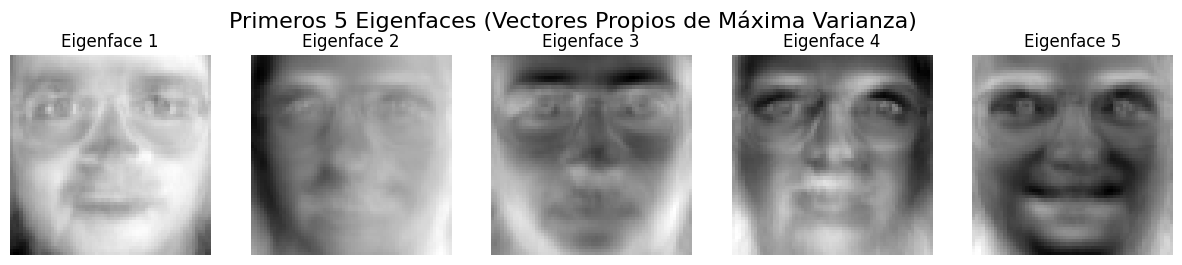

In [22]:
# --- EIGENFACES ---
# Un Eigenface es una fila de Vt, redimensionada a 64x64.
# Seleccionamos las primeras 5 filas (las de mayor varianza)

eigenfaces = Vt[:5]

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    # Redimensionamos el vector de 4096 a una matriz de 64x64
    eigenface_img = eigenfaces[i].reshape(64, 64)
    axes[i].imshow(eigenface_img, cmap='gray')
    axes[i].set_title(f"Eigenface {i+1}")
    axes[i].axis('off')

fig.suptitle("Primeros 5 Eigenfaces (Vectores Propios de Máxima Varianza)", fontsize=16)
plt.show()

**¿Qué características capturan los Eigenfaces?**

Matemáticamente, estos Eigenfaces son los vectores propios de la matriz de covarianza de los datos. Actúan como una base ortogonal; es decir, son los "bloques de construcción" fundamentales con los que se puede reconstruir cualquier rostro del dataset mediante una combinación lineal.

Al visualizar esto, vemos rostros "fantasmales". El Eigenface 1 (el primer componente principal) captura la fuente de mayor variación en todo el conjunto de datos. En este caso la iluminación. Los demás eigenfaces capturan estructuras geométricas predominantes, como la forma de la mandíbula, las cuencas de los ojos o el contorno de la nariz. ¡Son la "base matemática" con la que se puede armar cualquier rostro!

### **(d) Multipliquen los datos centrados por los primeros $k = 50$ componentes de $V^T$ para proyectar las imágenes originales a un nuevo espacio latente. Su nueva matriz de características será $Z ∈ R^{400×50}$**.

Aquí aplicamos la reducción de dimensionalidad.

Para proyectar nuestros datos, no necesitamos las $400$ dimensiones; el taller nos pide truncar esta matriz y quedarnos solo con los primeros $k=50$ componentes.

* Tomamos las primeras $50$ filas de $V^T$.

* Transponemos ese resultado para obtener una matriz $V_k$ de dimensiones $4096 \times 50$.

* Finalmente, realizamos el producto matricial o producto punto entre nuestra matriz de datos centrada ($400 \times 4096$) y nuestra matriz de componentes $V_k$ ($4096 \times 50$).

Por las reglas del álgebra lineal multivariada, el resultado será nuestra nueva matriz $Z$ de dimensiones $400 \times 50$

In [24]:
# --- PROYECCIÓN AL ESPACIO LATENTE ---
k = 50

# Extraer las primeras 50 filas de Vt y transponer para obtener V_k
# Vt[:k, :] toma las filas de 0 a 49 y todas las columnas. 
# .T transpone el resultado para que quede de (4096, 50)
V_k = Vt[:k, :].T 

# Proyectar los datos centrados al nuevo espacio latente Z mediante producto matricial
Z = np.dot(X_centrada, V_k)

# Comprobación de dimensiones para el informe
print(f"Dimensiones de X_centrada: {X_centrada.shape}")
print(f"Dimensiones de V_k (primeros {k} componentes): {V_k.shape}")
print(f"Dimensiones de la nueva matriz latente Z: {Z.shape}") # Debería ser (400, 50)

Dimensiones de X_centrada: (400, 4096)
Dimensiones de V_k (primeros 50 componentes): (4096, 50)
Dimensiones de la nueva matriz latente Z: (400, 50)


>**Para comprender mejor la relación de compresión y pérdida de información del proceso que hemos desarrollado hasta este punto realizaremos dos pasos adicionales:**

* (i) medir matemáticamente cuánta información ("varianza") retienen esos 50 componentes.

* (ii) realizaremos el proceso inverso para reconstruir nuestra imagen "Ancla" a partir de esos 50 componentes y la compararemos visualmente con la original.

Los primeros 50 componentes explican el 87.38% de la varianza total.


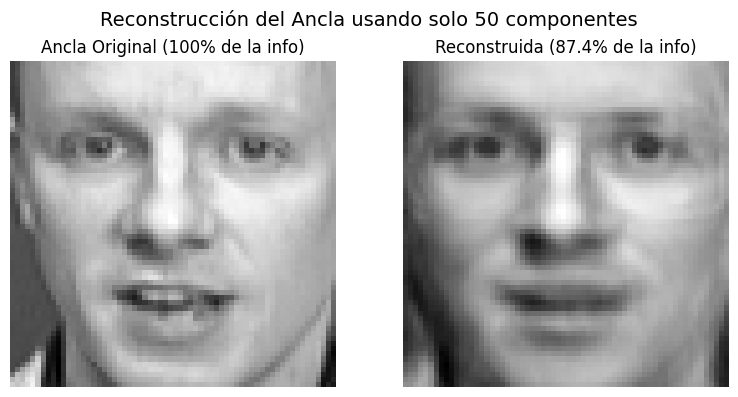

In [25]:
# --- PASO EXTRA: Varianza Explicada y Reconstrucción ---

# 1. Calcular la varianza explicada por los primeros k=50 componentes
# En la SVD, la varianza es proporcional al cuadrado de los valores singulares (S)
varianza_total = np.sum(S**2)
varianza_k50 = np.sum(S[:k]**2)

porcentaje_varianza = (varianza_k50 / varianza_total) * 100
print(f"Los primeros {k} componentes explican el {porcentaje_varianza:.2f}% de la varianza total.")

# 2. Reconstruir la imagen "Ancla" (índice 0) a partir de sus 50 coordenadas en Z
# Tomamos el vector del ancla en nuestro nuevo espacio latente Z (dimensiones: 50,)
z_ancla = Z[0]

# Hacemos la operación matemática inversa: 
# Multiplicamos por la matriz de componentes (Vk) y sumamos el rostro promedio que habíamos restado
ancla_reconstruida = np.dot(z_ancla, V_k.T) + rostro_promedio

# 3. Visualizar y comparar
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
fig.suptitle(f"Reconstrucción del Ancla usando solo {k} componentes", fontsize=14)

# Ancla Original (4096 píxeles reales)
axes[0].imshow(X[0].reshape(64, 64), cmap='gray')
axes[0].set_title("Ancla Original (100% de la info)")
axes[0].axis('off')

# Ancla Reconstruida (Desde 50 componentes)
axes[1].imshow(ancla_reconstruida.reshape(64, 64), cmap='gray')
axes[1].set_title(f"Reconstruida ({porcentaje_varianza:.1f}% de la info)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

El análisis nos indica que los primeros 50 componentes explican el 87.38% de la varianza total. Esto es un resultado espectacular del álgebra lineal ya que logramos reducir el tamaño de los datos en más de un 98% (de 4096 variables pasamos a solo 50), pero logramos retener la inmensa mayoría de la información estructural del rostro. 

Al reconstruir la imagen ancla usando solo 50 componentes principales notamos un muy buen desempeño considerando el cambio de dimensionalidad. Es bastante parecida a la original (inclinación, gesto facial, formas...), pero más "suavizada" y borrosa, perdiendo detalles finos. Esto ocurre porque la SVD actuó como un filtro de ruido. Al desechar los otros 350 componentes que capturaban el 10% restante de la varianza, matemáticamente eliminamos variaciones y detalles (como ruido estático de la cámara, arrugas muy diminutas o cambios ínfimos de luz). 

Este paso extra es la demostración visual y matemática de por qué nuestro espacio latente $Z \in \mathbb{R}^{400 \times 50}$ es tan poderoso, especialmente pensando en la clasificación que haremos en la Tarea 4 de este taller.

---

## **Tarea 3: Detección de Anomalías Sensible a la Correlación**

Verificaremos si el espacio latente es capaz de aislar datos atípicos usando estadística multivariada.

La detección de las anomalías o intruso entre las fotos vamos a usar la **Distancia de Mahalanobis**, debido a que esta distancia, a diferencia de la Distancia Eclidiana, como fue evaluado en los puntos anteriores, tiene en cuenta la varianza y la correlación entre las dimensiones del espacio latente.

Entrenado en detalle, el problema de usar la distancia Euclidiana en el espacio latente es que, aunque nuestras 50 características (Eigenfaces) son ortogonales, no tienen la misma "importancia". El Componente 1 captura muchísima más varianza natural que el Componente 50. La distancia Euclidiana asume que todas las dimensiones tienen la misma escala y forma una "esfera" perfecta alrededor del centroide. Si un rostro varía mucho en el Componente 1 (lo cual es normal, ej. cambios de luz) pero el intruso varía un poco en el Componente 50 (lo cual es estadísticamente imposible para un rostro humano), la distancia Euclidiana podría darles el mismo valor de "rareza", fallando en detectar la anomalía.

Por otro lado, Mahalanobis brilla pues, al incluir la matriz de covarianza inversa ($\Sigma^{-1}$) en la ecuación matemática, estandariza la varianza de cada eje y modela los datos como una "elipse" (un hiperelipsoide). Matemáticamente, penaliza fuertemente cualquier desviación en direcciones donde la varianza natural es baja (como los últimos componentes).

### **(a) Tomen la “imagen intrusa” descrita en la sección de datos, réstenle el rostro promedio y proyéctenla utilizando la misma transformación del paso anterior para obtener un vector intruso $z_{intruso} ∈ R^{50}$. Añádanlo a su matriz $Z$**

Se crea y proyecta la imagen intrusa. Para la creación de la imagen intrusa: la primera mitad del vector es `1.0` (blanco) y la segunda mitad `0.0` (negro). Luego la centramos con el mismo `rostro_promedio` de la Tarea 2 y la proyectamos al espacio latente con la misma transformación `V_k`.

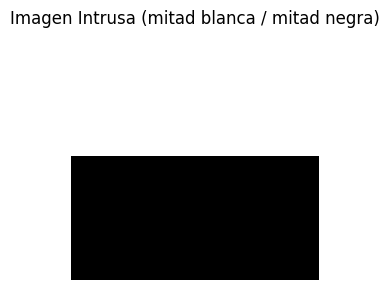

Forma del vector intruso proyectado: (50,)
Dimension de Z_ext (con intruso): (401, 50)


In [26]:
# Creamos la imagen intrusa: primera mitad = 1.0 (blanco), segunda mitad = 0.0 (negro)
imagen_intrusa = np.zeros(4096)
imagen_intrusa[:2048] = 1.0

# Visualizamos la imagen intrusa
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(imagen_intrusa.reshape(64, 64), cmap='gray')
ax.set_title('Imagen Intrusa (mitad blanca / mitad negra)')
ax.axis('off')
plt.tight_layout()
plt.show()

# Centramos la imagen intrusa con el mismo rostro_promedio de la Tarea 2
intrusa_centrada = imagen_intrusa - rostro_promedio

# Proyectamos al espacio latente usando V_k (4096 x 50)
z_intruso = intrusa_centrada @ V_k   # vector de R^50
print(f'Forma del vector intruso proyectado: {z_intruso.shape}')

# Añadimos el vector intruso a Z -> Z_ext de dimension (401, 50)
Z_ext = np.vstack([Z, z_intruso])
print(f'Dimension de Z_ext (con intruso): {Z_ext.shape}')

### **(b) En este espacio de 50 dimensiones, calculen la Distancia de Mahalanobis de todas las imágenes respecto al centroide global del dataset1. Recuerden que este cálculo requiere estimar e invertir la matriz de covarianza de Z.**

En este literal vamos a hallar la **Distancia de Mahalanobis** al centroide global que es el vector de medías multivariado como lo indica la nota en el enunciado. Lo que quiere decir, que no solo se busca medir la distancia del centroide al punto determinado, sino que también se mide que tan diferente es ese punto del resto de puntos.

Entonces, se tiene que la Distancia de Mahalanobis para una observación $\mathbf{z}_i$ respecto al centroide global $\bar{\mathbf{z}}$ se define como:

$$D^2_i = (\mathbf{z}_i - \bar{\mathbf{z}})^\top \mathbf{S}^{-1} (\mathbf{z}_i - \bar{\mathbf{z}})$$

donde $\mathbf{S}$ es la matriz de covarianza de $Z_{ext} \in \mathbb{R}^{401 \times 50}$, que son la 400 imagenes reales y la imagen intrusa. Como se vio en clase, esta métrica es un **producto interno ponderado** $\langle x, y \rangle_{S^{-1}} = x^\top S^{-1} y$ que normaliza cada dirección por su varianza y descorrelaciona las dimensiones, logrando una medida de distancia estadística genuina.

In [27]:
# Centroide global del espacio latente (media por dimension)
centroide = np.mean(Z_ext, axis=0)   # Vector de R^50
print(f'Forma del centroide: {centroide.shape}')

# Matriz de covarianza de Z_ext (50 x 50)
# np.cov espera variables en filas, por eso transponemos
S = np.cov(Z_ext.T)
print(f'Forma de la matriz de covarianza S: {S.shape}')

# Invertimos la matriz de covarianza
S_inv = np.linalg.inv(S)

# Calculamos D^2_i para cada imagen (las 401 filas)
N_ext = Z_ext.shape[0]
distancias_maha = np.zeros(N_ext)

for i in range(N_ext):
    diff = Z_ext[i] - centroide
    distancias_maha[i] = diff @ S_inv @ diff

print(f'\nDistancia Mahalanobis de la imagen intrusa (indice 400): {distancias_maha[400]:.2f}')
print(f'Distancia maxima de las imagenes reales (0-399): {distancias_maha[:400].max():.2f}')
print(f'Distancia media de las imagenes reales: {distancias_maha[:400].mean():.2f}')

Forma del centroide: (50,)
Forma de la matriz de covarianza S: (50, 50)

Distancia Mahalanobis de la imagen intrusa (indice 400): 242.90
Distancia maxima de las imagenes reales (0-399): 128.83
Distancia media de las imagenes reales: 49.39


### **(c) Grafiquen un histograma de las distancias calculadas y marquen con una línea vertical roja u otro color llamativo dónde quedó ubicada la imagen intrusa.**

Se realiza un histograma para visualizar las ditancias entre de las imagenes reales y la intrusa, para verificar lo que detectamos matemáticamente.

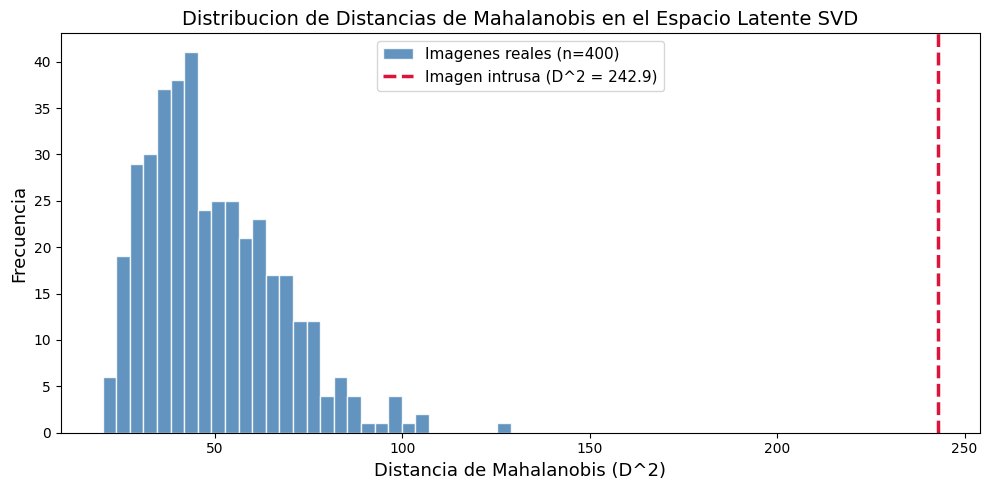

Percentil 99 de imagenes reales: 99.16
La intrusa supera al 100.0% de las imagenes reales.


In [28]:
fig, ax = plt.subplots(figsize=(10, 5))

# Histograma de las 400 imagenes reales
ax.hist(distancias_maha[:400], bins=30, color='steelblue', edgecolor='white',
        alpha=0.85, label='Imagenes reales (n=400)')

# Linea vertical para la imagen intrusa
ax.axvline(distancias_maha[400], color='crimson', linewidth=2.5, linestyle='--',
           label=f'Imagen intrusa (D^2 = {distancias_maha[400]:.1f})')

ax.set_xlabel('Distancia de Mahalanobis (D^2)', fontsize=13)
ax.set_ylabel('Frecuencia', fontsize=13)
ax.set_title('Distribucion de Distancias de Mahalanobis en el Espacio Latente SVD', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f'Percentil 99 de imagenes reales: {np.percentile(distancias_maha[:400], 99):.2f}')
print(f'La intrusa supera al {(distancias_maha[400] > distancias_maha[:400]).mean()*100:.1f}% de las imagenes reales.')

### **(d) Discusión: Dado que las características en el espacio latente SVD son ortogonales, analicen matemáticamente por qué la métrica de Mahalanobis, al incluir la matriz de covarianza, es superior a una simple distancia Euclidiana para confirmar que esa imagen es un outlier**

Dado que las características en el espacio latente SVD (Singular Value Decomposition) son ortogonales por construcción 
(las columnas de $V_k$ forman una base ortonormal), las componentes de $Z$ son 
**incorreladas entre sí**. Esto implica que la matriz de covarianza $\mathbf{S}$ es 
aproximadamente diagonal:

$$\mathbf{S} \approx \text{diag}(\sigma_1^2, \sigma_2^2, \ldots, \sigma_{50}^2)$$

donde $\sigma_1^2 \gg \sigma_2^2 \gg \cdots \gg \sigma_{50}^2$, pues los valores 
singulares de la SVD van decreciendo en orden.

Como $\mathbf{S}$ es diagonal, su inversa también lo es:

$$\mathbf{S}^{-1} \approx \text{diag}(1/\sigma_1^2, 1/\sigma_2^2, \ldots, 1/\sigma_{50}^2)$$

Con esto, la distancia de Mahalanobis se simplifica a:

$$D^2_i = \sum_{j=1}^{50} \frac{(z_{ij} - \bar{z}_j)^2}{\sigma_j^2}$$

Comparándola directamente con la Euclidiana:

$$d_E^2 = \sum_{j=1}^{50} (z_{ij} - \bar{z}_j)^2$$

La diferencia estructural es el factor $1/\sigma_j^2$: Mahalanobis **pondera cada 
dimensión por el inverso de su varianza**. Las últimas componentes tienen $\sigma_j^2$ 
muy pequeño (casi no varían entre rostros reales), por lo que $1/\sigma_j^2$ es muy 
grande. La imagen intrusa, al ser estructuralmente incompatible con cualquier cara 
humana, presenta desviaciones significativas precisamente en esas componentes de baja 
varianza, lo que dispara su $D^2$ a 242.90 — superando en casi el doble a la imagen 
real más alejada (128.83).

La distancia Euclidiana, al tratar todas las dimensiones por igual, subestimaría 
sistemáticamente la rareza estadística de la intrusa en esas componentes. Por eso 
Mahalanobis no mide distancia geométrica sino **rareza estadística**, y es la métrica 
correcta para este problema.

---

## **Tarea 4: Optimización Convexa: Clasificación Binaria**

---